In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
file_path = "/content/drive/My Drive/Colab Notebooks/IPD/dataset.csv"

# Read the first few rows to inspect the structure
df = pd.read_csv(file_path)

# Display basic info
print(df.info())
print(df.head())

# Handle missing values (Drop rows with missing values)
df = df.dropna()

# Encode the categorical "Physical_Activity_Level" column
activity_mapping = {"Sedentary": 0, "Moderate": 1, "Active": 2}  # Define mapping
df["Physical_Activity_Level"] = df["Physical_Activity_Level"].map(activity_mapping)

# Ensure all values are now numeric
print(df.head())  # Check if transformation is applied

# Features and target variable
X = df[['Age', 'BMI', 'Physical_Activity_Level']]
y = df['Daily_Caloric_Intake']

# Split the data into Training & Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Save the scaler for later use in the Flask backend
joblib.dump(scaler, "/content/drive/MyDrive/Colab Notebooks/IPD/scaler.pkl")

# --- UPGRADED NEURAL NETWORK ARCHITECTURE ---
from tensorflow.keras.callbacks import EarlyStopping

# 1. Build a deeper, wider Neural Network
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='linear')  # Output: Predicted caloric need
])

# 2. Use a custom learning rate so the model can reach large numbers (2000s) faster
custom_optimizer = keras.optimizers.Adam(learning_rate=0.01)

# 3. Compile the model
model.compile(optimizer=custom_optimizer, loss='mse', metrics=['mae'])

# 4. Add Early Stopping (Stops training when it reaches peak accuracy)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# 5. Train the model (Increased to 500 epochs)
print("Training upgraded model...")
history = model.fit(
    X_train_scaled, y_train,
    epochs=500,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 6. Save the newly trained model
model.save("/content/drive/MyDrive/Colab Notebooks/IPD/nutrition_model.keras")

# Evaluate new MAE
y_pred = model.predict(X_test_scaled)
from sklearn.metrics import mean_absolute_error
new_mae = mean_absolute_error(y_test, y_pred)
print(f"\nSUCCESS! New Model MAE is now: {new_mae:.2f}")

Mounted at /content/drive
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Patient_ID                        1000 non-null   object 
 1   Age                               1000 non-null   int64  
 2   Gender                            1000 non-null   object 
 3   Weight_kg                         1000 non-null   float64
 4   Height_cm                         1000 non-null   int64  
 5   BMI                               1000 non-null   float64
 6   Disease_Type                      796 non-null    object 
 7   Severity                          1000 non-null   object 
 8   Physical_Activity_Level           1000 non-null   object 
 9   Daily_Caloric_Intake              1000 non-null   int64  
 10  Cholesterol_mg/dL                 1000 non-null   float64
 11  Blood_Pressure_mmHg               1000 non-n

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 6506076.5000 - mae: 2483.1323 - val_loss: 6233875.0000 - val_mae: 2443.0347
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 6430435.5000 - mae: 2467.9678 - val_loss: 6035055.0000 - val_mae: 2401.6204
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 6049787.5000 - mae: 2389.0212 - val_loss: 5216918.0000 - val_mae: 2223.1814
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4747835.5000 - mae: 2096.2170 - val_loss: 3047547.5000 - val_mae: 1655.4746
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 2060815.5000 - mae: 1275.9127 - val_loss: 516450.6250 - val_mae: 566.4230
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 693749.7500 - mae: 700.4944 - val_loss: 979493.9375 - val_mae: 824.3945
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 553599.1875 - mae: 613.3051 - val_loss: 419196.0625 - val_mae: 513.2411
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 440761.468

In [2]:
# Load required libraries
import numpy as np
import joblib
from tensorflow import keras

# Load the saved model and scaler
model = keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/IPD/nutrition_model.keras")
scaler = joblib.load("/content/drive/MyDrive/Colab Notebooks/IPD/scaler.pkl")

# Sample test input (age=30, BMI=22, activity=Moderate)
sample_input = np.array([[30, 22, 1]])  # Using 1 for "Moderate" activity

# Scale input
sample_input_scaled = scaler.transform(sample_input)

# Predict caloric intake
predicted_calories = model.predict(sample_input_scaled)
print(f"Predicted Daily Caloric Intake: {predicted_calories[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Predicted Daily Caloric Intake: 2448.96


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [3]:
# Load dataset again for testing
df_test = pd.read_csv("/content/drive/My Drive/Colab Notebooks/IPD/dataset.csv").dropna()

# Encode Physical_Activity_Level
df_test["Physical_Activity_Level"] = df_test["Physical_Activity_Level"].map(activity_mapping)

# Split test data
X_test = df_test[['Age', 'BMI', 'Physical_Activity_Level']]
y_test = df_test['Daily_Caloric_Intake']

# Scale test features
X_test_scaled = scaler.transform(X_test)

# Predict
y_pred = model.predict(X_test_scaled)

# Display first few results
results = pd.DataFrame({'Actual': y_test[:5].values, 'Predicted': y_pred[:5].flatten()})
print(results)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
   Actual    Predicted
0    1777  2801.066162
1    1622  2409.391113
2    3257  2497.286377
3    2574  2408.856201
4    3083  2419.730225


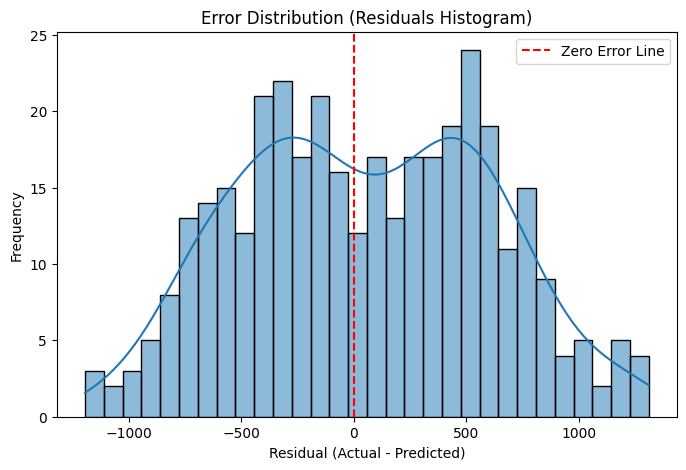

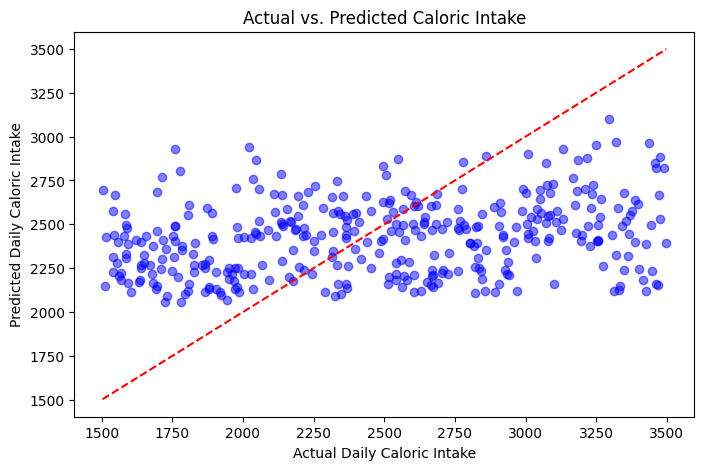

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute residuals
residuals = y_test - y_pred.flatten()

# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Error Distribution (Residuals Histogram)")
plt.axvline(x=0, color='r', linestyle='--', label="Zero Error Line")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r', linestyle='--')  # Ideal 45-degree line
plt.xlabel("Actual Daily Caloric Intake")
plt.ylabel("Predicted Daily Caloric Intake")
plt.title("Actual vs. Predicted Caloric Intake")
plt.show()

In [5]:
import time

# Measure prediction time for a batch
start_time = time.time()
model.predict(X_test_scaled)
end_time = time.time()

execution_time = end_time - start_time
print(f"Time taken for batch prediction: {execution_time:.4f} seconds")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
Time taken for batch prediction: 0.1915 seconds


In [6]:
# Simulate large input data
large_input = np.tile(X_test_scaled, (100, 1))  # Replicate data 100 times

# Measure time taken
start_time = time.time()
large_predictions = model.predict(large_input)
end_time = time.time()

print(f"Predictions for large input completed in {end_time - start_time:.4f} seconds")

1141/1141 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Predictions for large input completed in 2.7937 seconds


In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate errors
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred.flatten()) / y_test)) * 100

# Display results
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Mean Absolute Error (MAE): 467.99
Root Mean Squared Error (RMSE): 552.21
Mean Absolute Percentage Error (MAPE): 20.02%


In [8]:
# Add random noise to test data
noise = np.random.normal(0, 0.1, X_test_scaled.shape)
X_noisy = X_test_scaled + noise

# Predict on noisy data
y_noisy_pred = model.predict(X_noisy)

# Evaluate performance on noisy data
mae_noisy = mean_absolute_error(y_test, y_noisy_pred)
rmse_noisy = np.sqrt(mean_squared_error(y_test, y_noisy_pred))
mape_noisy = np.mean(np.abs((y_test - y_noisy_pred.flatten()) / y_test)) * 100

print(f"MAE with Noise: {mae_noisy:.2f}")
print(f"RMSE with Noise: {rmse_noisy:.2f}")
print(f"MAPE with Noise: {mape_noisy:.2f}%")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
MAE with Noise: 471.21
RMSE with Noise: 555.77
MAPE with Noise: 20.18%


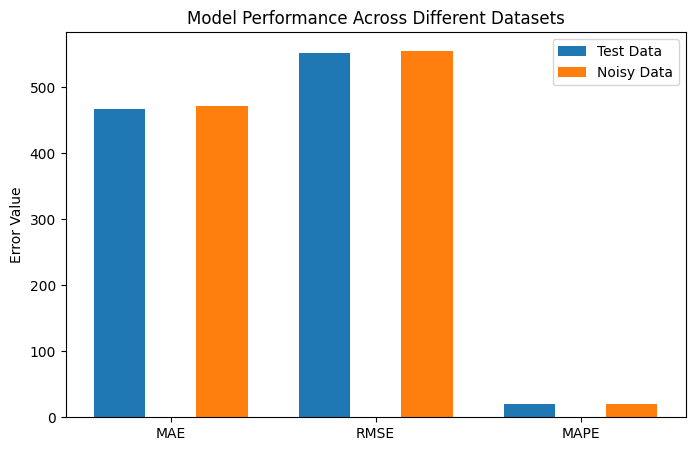

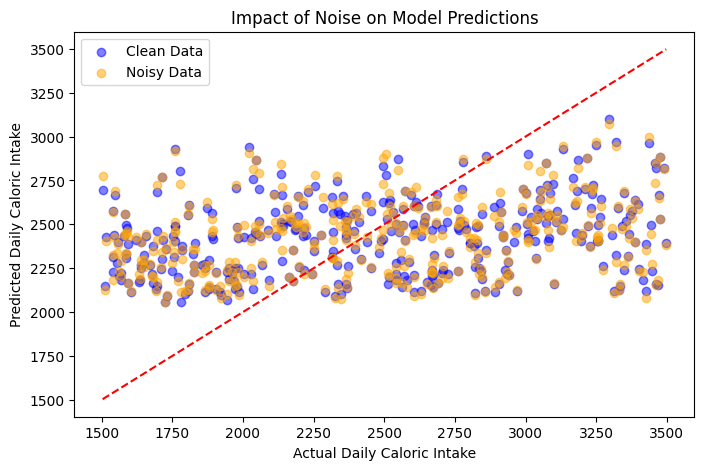

In [9]:
import numpy as np

# Metric values
metrics = ["MAE", "RMSE", "MAPE"]
test_values = [mae, rmse, mape]
noisy_values = [mae_noisy, rmse_noisy, mape_noisy]

# Bar chart
x = np.arange(len(metrics))
width = 0.25  # Bar width

plt.figure(figsize=(8, 5))
plt.bar(x - width, test_values, width, label="Test Data")
plt.bar(x + width, noisy_values, width, label="Noisy Data")

plt.xticks(ticks=x, labels=metrics)
plt.ylabel("Error Value")
plt.title("Model Performance Across Different Datasets")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, label="Clean Data", color="blue")
plt.scatter(y_test, y_noisy_pred, alpha=0.5, label="Noisy Data", color="orange")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r', linestyle='--')  # Ideal line
plt.xlabel("Actual Daily Caloric Intake")
plt.ylabel("Predicted Daily Caloric Intake")
plt.title("Impact of Noise on Model Predictions")
plt.legend()
plt.show()

In [10]:
# Extreme low and high values
edge_cases = np.array([
    [10, 10, 0],   # Very young, low BMI, sedentary
    [90, 40, 2],   # Very old, high BMI, active
])

# Scale input
edge_cases_scaled = scaler.transform(edge_cases)

# Predict
edge_predictions = model.predict(edge_cases_scaled)

# Display results
for i, pred in enumerate(edge_predictions.flatten()):
    print(f"Edge Case {i+1} - Predicted Calories: {pred:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Edge Case 1 - Predicted Calories: 3222.76
Edge Case 2 - Predicted Calories: 2245.03


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [11]:
import numpy as np
import pandas as pd

# 1. Inspect the original training dataset statistics
print("--- Dataset Caloric Intake Statistics ---")
display(df['Daily_Caloric_Intake'].describe())

# 2. Manual Test: Age 26, BMI 24.7, Sedentary (0)
test_input = np.array([[26, 24.7, 0]])

# Scale the manual input using the existing scaler
test_input_scaled = scaler.transform(test_input)

# Predict using the existing model
manual_prediction = model.predict(test_input_scaled)

print(f"\n--- Manual Test Prediction ---")
print(f"Input: Age 26, BMI 24.7, Activity 0")
print(f"Predicted Daily Caloric Intake: {manual_prediction[0][0]:.2f} kcal")

--- Dataset Caloric Intake Statistics ---


,Daily_Caloric_Intake
count,365.000000
mean,2477.265753
std,571.125227
min,1503.000000
25%,1977.000000
50%,2509.000000
75%,2943.000000
max,3498.000000


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step

--- Manual Test Prediction ---
Input: Age 26, BMI 24.7, Activity 0
Predicted Daily Caloric Intake: 2515.34 kcal
